# FYP Implementation: Reddit Trend Emergence Prediction

This notebook contains the cleaned final implementation of the Reddit trend-emergence prediction pipeline. The workflow moves from dataset inspection and trend labelling to chronological model selection, deployment design on validation data, held-out test evaluation, robustness checks, and the final moderator dashboard.

# 1. Setup

Dataset: https://www.kaggle.com/datasets/stefano1283/reddit-topic-dataset

## Import Required Libraries

This section imports the main libraries used in the project. `pandas` is used for tabular data processing, `duckdb` is used to query large Parquet files efficiently without loading the full dataset into memory, `matplotlib` is used for visualisation, `numpy` is used for handling missing and infinite numerical values, and `pyarrow` is used to inspect Parquet metadata.

In [36]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, average_precision_score)
from sklearn.model_selection import TimeSeriesSplit
from IPython.display import display

### Optional package installation
Uncomment these commands only if the required packages are not already installed.

In [37]:
# Uncomment and Install once

# %pip install pandas numpy pyarrow duckdb matplotlib scikit-learn

# 2. Dataset Inspection and Scope

## Inspecting the Main Reddit Topic Dataset

The main dataset is stored in Parquet format which is suitable for large-scale data. Before loading any data, the file metadata is inspected to check the number of rows, number of columns and available fields. This helps confirm whether the dataset contains the required information for time-based Reddit trend detection.

In [38]:
file_path = "final_dataframe_with_topics.parquet"

parquet_file = pq.ParquetFile(file_path)

print("Number of rows:", parquet_file.metadata.num_rows)
print("Number of columns:", parquet_file.metadata.num_columns)
print("Columns:")
print(parquet_file.schema)

Number of rows: 43517561
Number of columns: 8
Columns:
required group field_id=-1 schema {
  optional binary field_id=-1 id (String);
  optional binary field_id=-1 subreddit (String);
  optional int64 field_id=-1 created_utc;
  optional binary field_id=-1 author (String);
  optional int64 field_id=-1 cluster;
  optional int64 field_id=-1 subcluster;
  optional binary field_id=-1 topic (String);
  optional binary field_id=-1 topic_subcluster (String);
}



In [39]:
subreddit_summary = duckdb.sql(f"""
    SELECT
        subreddit,
        COUNT(*) AS total_rows,
        COUNT(DISTINCT topic) AS unique_topics,
        COUNT(DISTINCT CAST(to_timestamp(created_utc) AS DATE)) AS active_days,
        MIN(CAST(to_timestamp(created_utc) AS DATE)) AS first_date,
        MAX(CAST(to_timestamp(created_utc) AS DATE)) AS last_date
    FROM read_parquet('{file_path}')
    WHERE topic IS NOT NULL
    GROUP BY subreddit
    HAVING COUNT(*) >= 10000
    ORDER BY unique_topics DESC, total_rows DESC
""").df()

subreddit_summary.head(30)

,subreddit,total_rows,unique_topics,active_days,first_date,last_date
0,aww,300464,274,4232,2008-02-09,2023-01-01
1,pics,197977,274,4805,2008-01-26,2023-01-01
2,memes,178505,274,2784,2011-10-14,2023-01-01
3,teenagers,120381,274,3496,2011-08-31,2023-01-01
4,PewdiepieSubmissions,114639,274,1641,2017-06-18,2023-01-01
5,gaming,85154,274,4710,2008-01-06,2023-01-01
6,dankmemes,79768,274,2262,2015-01-26,2023-01-01
7,The_Donald,505097,273,1403,2015-08-13,2020-03-07
8,funny,134813,273,4744,2008-02-08,2023-01-01
9,trees,108576,273,4272,2009-10-16,2023-01-01


In [40]:
# Inspect raw dataset columns and 20 sample rows

sample_raw = duckdb.sql(f"""
    SELECT *
    FROM read_parquet('{file_path}')
    LIMIT 20
""").df()

sample_raw

,id,subreddit,created_utc,author,cluster,subcluster,topic,topic_subcluster
0,9fqn2j,forhonorknights,1536918349,jman797,87,689,national identity and symbols,flags and symbolism
1,9fqnj2,TrollXChromosomes,1536918498,ayane_m,190,1744,Communication and Emotions,Communication and Emotion
2,9fqnsb,JerkOffToCelebs,1536918573,hectoralxram,127,1051,Relationships and Personal Reflections,Relationships and Experiences
3,9fqo3a,Badfaketexts,1536918679,AshleyBoyd,3,-1,Dinosaurs,None
4,9fqo4l,thewalkingdead,1536918690,cerealkiller221b,197,-1,TV shows and spoilers,None
5,9fqoot,stopdrinking,1536918883,chalkyfish,229,2126,Alcohol Consumption and Sobriety,alcohol and sobriety
6,9fqoqb,cakedecorating,1536918899,Notnotnotbryan,268,2450,birthday desserts,desserts
7,9fqore,FemBoys,1536918909,CouldbeAshley,254,-1,underwear fashion,None
8,9fqotu,childfree,1536918933,Gieselbrecht,117,985,language learning,language learning
9,9fqoud,CAKEWIN,1536918938,Notnotnotbryan,268,2450,birthday desserts,desserts


In [41]:
selected_subreddits = ["aww", "AskReddit", "memes", "pics", "funny"]

subreddit_summary[
    subreddit_summary["subreddit"].isin(selected_subreddits)
]

,subreddit,total_rows,unique_topics,active_days,first_date,last_date
0,aww,300464,274,4232,2008-02-09,2023-01-01
1,pics,197977,274,4805,2008-01-26,2023-01-01
2,memes,178505,274,2784,2011-10-14,2023-01-01
8,funny,134813,273,4744,2008-02-08,2023-01-01
24,AskReddit,160248,269,4725,2008-02-08,2023-01-01


## Creating a Smaller Working Subset

The final implementation uses five selected subreddits: aww, AskReddit, memes, pics and funny. This keeps processing manageable while retaining broad topic diversity and long temporal coverage for evaluating trend emergence across different communities.

In [42]:
daily_topic_counts_small = duckdb.sql(f"""
    select
        cast(to_timestamp(created_utc) as date) as date,
        subreddit,
        topic,
        count(*) as mention_volume
    from read_parquet('{file_path}')
    where topic is not null
      and subreddit in ('aww', 'AskReddit', 'memes', 'pics', 'funny')
    group by date, subreddit, topic
    order by date, subreddit, topic
""").df()

daily_topic_counts_small.head()

,date,subreddit,topic,mention_volume
0,2008-01-26,pics,The Office Characters and Relationships,1
1,2008-01-28,pics,houseplants,1
2,2008-01-28,pics,wallpapers,1
3,2008-01-29,pics,beauty and skincare,1
4,2008-02-02,pics,Halloween celebrations,1


# 3. Daily Time-Series Construction

## Preparing Data for Complete Daily Time Series

The initial daily topic table only includes days where a topic appeared at least once. For a time-based trend definition, days with no mentions should also be represented as zero activity. This step selects the required columns before filling missing dates.

## Function for Filling Missing Dates

This function creates a complete daily date range for each subreddit-topic pair. Missing dates are added and their mention volume is set to zero. This is necessary because zero-mention days should contribute to the 7-day rolling baseline instead of being ignored.

In [43]:
def fill_missing_dates(group):
    subreddit, topic = group.name

    full_dates = pd.date_range(
        start=group["date"].min(),
        end=group["date"].max(),
        freq="D"
    )

    group = group.set_index("date").reindex(full_dates)
    group.index.name = "date"

    group["subreddit"] = subreddit
    group["topic"] = topic
    group["mention_volume"] = group["mention_volume"].fillna(0)

    return group.reset_index()

daily_complete = (
    daily_topic_counts_small
    .groupby(["subreddit", "topic"])
    .apply(fill_missing_dates, include_groups=False)
    .reset_index(drop=True)
)

In [44]:
daily_complete[
    (daily_complete["subreddit"] == "AskReddit") &
    (daily_complete["topic"] == "3D Printing")
][["date", "subreddit", "topic", "mention_volume"]].head(10)

,date,subreddit,topic,mention_volume
0,2009-05-07,AskReddit,3D Printing,1.0
1,2009-05-08,AskReddit,3D Printing,0.0
2,2009-05-09,AskReddit,3D Printing,0.0
3,2009-05-10,AskReddit,3D Printing,0.0
4,2009-05-11,AskReddit,3D Printing,0.0
5,2009-05-12,AskReddit,3D Printing,0.0
6,2009-05-13,AskReddit,3D Printing,0.0
7,2009-05-14,AskReddit,3D Printing,0.0
8,2009-05-15,AskReddit,3D Printing,0.0
9,2009-05-16,AskReddit,3D Printing,0.0


## Calculating Rolling Average and Growth Ratio

In [45]:
daily_complete = daily_complete.sort_values(
    ["subreddit", "topic", "date"]
).copy()

daily_complete["rolling_7day_avg"] = (
    daily_complete
    .groupby(["subreddit", "topic"])["mention_volume"]
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=7).mean())
)

daily_complete["growth_ratio"] = (
    daily_complete["mention_volume"] / daily_complete["rolling_7day_avg"]
)

daily_complete.head()

,date,mention_volume,subreddit,topic,rolling_7day_avg,growth_ratio
0,2009-05-07,1.0,AskReddit,3D Printing,NaN,NaN
1,2009-05-08,0.0,AskReddit,3D Printing,NaN,NaN
2,2009-05-09,0.0,AskReddit,3D Printing,NaN,NaN
3,2009-05-10,0.0,AskReddit,3D Printing,NaN,NaN
4,2009-05-11,0.0,AskReddit,3D Printing,NaN,NaN


# 4. Trend Labelling and Visual Validation

## Creating Trend Label

In [46]:
# Replace infinite values
daily_complete["growth_ratio"] = daily_complete["growth_ratio"].replace(
    [np.inf, -np.inf], np.nan
)

# Recreate trend label safely
daily_complete["is_trend"] = (
    (daily_complete["rolling_7day_avg"] > 0) &
    (daily_complete["growth_ratio"] >= 3) &
    (daily_complete["mention_volume"] >= 20)
).astype(int)

# Check result
print("NaN growth_ratio:", daily_complete["growth_ratio"].isna().sum())
print("Infinite growth_ratio:", np.isinf(daily_complete["growth_ratio"]).sum())
print(daily_complete["is_trend"].value_counts())
print(daily_complete["is_trend"].value_counts(normalize=True) * 100)

NaN growth_ratio: 4086795
Infinite growth_ratio: 0
is_trend
0    5726138
1        364
Name: count, dtype: int64
is_trend
0    99.993644
1     0.006356
Name: proportion, dtype: float64


Rows with undefined feature values were removed before modelling. These include early observations without sufficient rolling history and observations where the previous seven-day average was zero, making the growth ratio undefined after infinite values were replaced with NaN.

The final trend-labelling procedure identifies 364 trend rows and 5,726,138 non-trend rows. Therefore, only approximately 0.0064% of completed daily subreddit-topic observations satisfy the operational trend definition. This demonstrates that trend emergence is an extremely rare event within the dataset and explains why overall classification accuracy is not an informative evaluation measure for this project.

## Visualising a Final Detected Trend

Selected trend example:
date                2019-04-25 00:00:00
subreddit                           aww
topic                              cats
mention_volume                    478.0
rolling_7day_avg              94.857143
growth_ratio                   5.039157
Name: 1762887, dtype: object


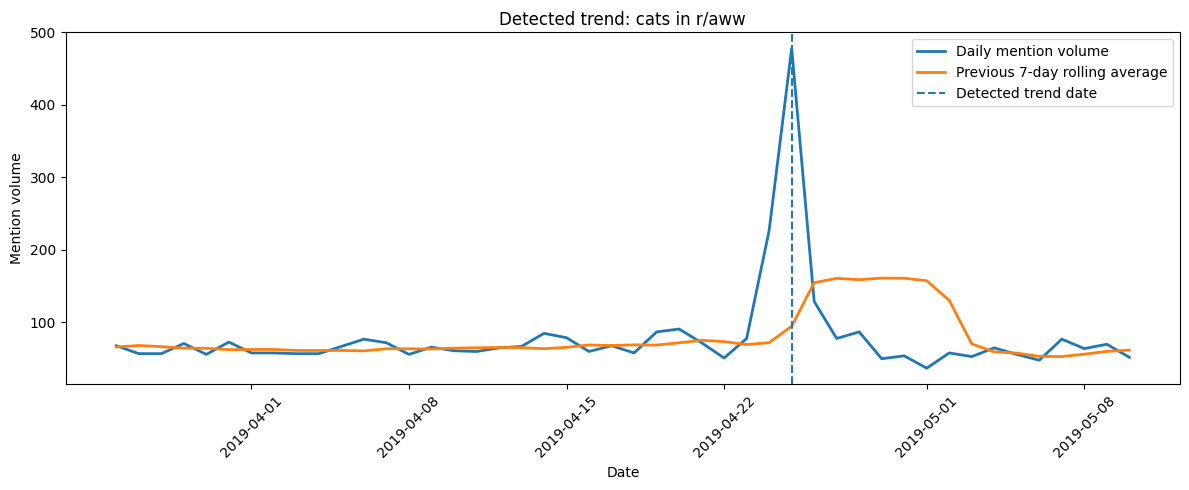

In [47]:
# Keep only final trend rows
trends_complete = daily_complete[
    daily_complete["is_trend"] == 1
].copy()

# Select one clear example
example = trends_complete.sort_values(
    ["mention_volume", "growth_ratio"],
    ascending=False
).iloc[0]

subreddit = example["subreddit"]
topic = example["topic"]
trend_date = pd.to_datetime(example["date"])

print("Selected trend example:")
print(example[[
    "date",
    "subreddit",
    "topic",
    "mention_volume",
    "rolling_7day_avg",
    "growth_ratio"
]])

# Get the full time series for this subreddit-topic pair
plot_df = daily_complete[
    (daily_complete["subreddit"] == subreddit) &
    (daily_complete["topic"] == topic)
].copy()

plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df = plot_df.sort_values("date")

# Focus on activity around the detected trend date
start_date = trend_date - pd.Timedelta(days=30)
end_date = trend_date + pd.Timedelta(days=15)

focus_df = plot_df[
    (plot_df["date"] >= start_date) &
    (plot_df["date"] <= end_date)
]

# Plot daily activity and the previous 7-day baseline
plt.figure(figsize=(12, 5))

plt.plot(
    focus_df["date"],
    focus_df["mention_volume"],
    linewidth=2,
    label="Daily mention volume"
)

plt.plot(
    focus_df["date"],
    focus_df["rolling_7day_avg"],
    linewidth=2,
    label="Previous 7-day rolling average"
)

plt.axvline(
    trend_date,
    linestyle="--",
    label="Detected trend date"
)

plt.title(f"Detected trend: {topic} in r/{subreddit}")
plt.xlabel("Date")
plt.ylabel("Mention volume")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

The selected example from r/aww shows the topic cats on 25 April 2019. Mention volume increased to 478, compared with a previous seven-day average of approximately 94.9, producing a growth ratio of about 5.04. Because the volume exceeds 20 mentions and the growth ratio exceeds the three-times threshold, the topic is labelled as a trend. The example provides a visual sanity check that the operational trend definition captures sudden increases relative to recent historical activity.

# 5. Modelling Dataset and Feature Engineering

## Final Modelling Dataset Preparation

In [48]:
model_df = daily_complete.sort_values(
    ["subreddit", "topic", "date"]
).copy()

# Ensure date is datetime
model_df["date"] = pd.to_datetime(model_df["date"])

# Create next-day prediction target
model_df["target_trend_next_day"] = (
    model_df
    .groupby(["subreddit", "topic"])["is_trend"]
    .shift(-1)
)

# Create lag features
model_df["lag_1"] = (
    model_df
    .groupby(["subreddit", "topic"])["mention_volume"]
    .shift(1)
)

model_df["lag_2"] = (
    model_df
    .groupby(["subreddit", "topic"])["mention_volume"]
    .shift(2)
)

model_df["lag_3"] = (
    model_df
    .groupby(["subreddit", "topic"])["mention_volume"]
    .shift(3)
)

# Change in volume from previous day
model_df["volume_change"] = model_df["mention_volume"] - model_df["lag_1"]

# Day of week: Monday = 0, Sunday = 6
model_df["day_of_week"] = model_df["date"].dt.dayofweek

# Final enhanced feature set
enhanced_features = [
    "mention_volume",
    "rolling_7day_avg",
    "growth_ratio",
    "lag_1",
    "lag_2",
    "lag_3",
    "volume_change",
    "day_of_week"
]

# Remove rows with missing values
enhanced_ml_df = model_df.dropna(
    subset=enhanced_features + ["target_trend_next_day"]
).copy()

# Convert target to integer
enhanced_ml_df["target_trend_next_day"] = (
    enhanced_ml_df["target_trend_next_day"].astype(int)
)

print("Enhanced modelling dataset shape:", enhanced_ml_df.shape)
print("\nTarget distribution:")
print(enhanced_ml_df["target_trend_next_day"].value_counts())
print("\nTarget distribution (%):")
print(enhanced_ml_df["target_trend_next_day"].value_counts(normalize=True) * 100)

Enhanced modelling dataset shape: (1639374, 13)

Target distribution:
target_trend_next_day
0    1639028
1        346
Name: count, dtype: int64

Target distribution (%):
target_trend_next_day
0    99.978894
1     0.021106
Name: proportion, dtype: float64


After creating the next-day prediction target, lag features and other temporal variables and removing rows without sufficient historical information, the final modelling dataset contains 1,639,374 rows. Of these, only 346 rows are labelled as next-day trend cases, corresponding to approximately 0.0211% of the modelling data. The prediction task is therefore extremely imbalanced, with the model required to rank a very small number of future trend events among a much larger number of normal observations.

# 6. Chronological Train, Validation and Test Split

In [49]:
# Sort by date to preserve time order
enhanced_ml_df = enhanced_ml_df.sort_values("date").copy()

# Use unique dates so that the same date does not appear in multiple splits
unique_dates = enhanced_ml_df["date"].sort_values().unique()

train_end_idx = int(len(unique_dates) * 0.70)
val_end_idx = int(len(unique_dates) * 0.85)

train_end_date = unique_dates[train_end_idx]
val_end_date = unique_dates[val_end_idx]

train_df = enhanced_ml_df[
    enhanced_ml_df["date"] < train_end_date
].copy()

val_df = enhanced_ml_df[
    (enhanced_ml_df["date"] >= train_end_date) &
    (enhanced_ml_df["date"] < val_end_date)
].copy()

test_df = enhanced_ml_df[
    enhanced_ml_df["date"] >= val_end_date
].copy()

print("Train date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Validation date range:", val_df["date"].min(), "to", val_df["date"].max())
print("Test date range:", test_df["date"].min(), "to", test_df["date"].max())

print("\nRows:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTarget distribution:")
print("Train:")
print(train_df["target_trend_next_day"].value_counts())

print("\nValidation:")
print(val_df["target_trend_next_day"].value_counts())

print("\nTest:")
print(test_df["target_trend_next_day"].value_counts())

Train date range: 2008-02-02 00:00:00 to 2018-09-19 00:00:00
Validation date range: 2018-09-20 00:00:00 to 2020-11-09 00:00:00
Test date range: 2020-11-10 00:00:00 to 2022-12-31 00:00:00

Rows:
Train: 901294
Validation: 428395
Test: 309685

Target distribution:
Train:
target_trend_next_day
0    901150
1       144
Name: count, dtype: int64

Validation:
target_trend_next_day
0    428249
1       146
Name: count, dtype: int64

Test:
target_trend_next_day
0    309629
1        56
Name: count, dtype: int64


In [50]:
X_train = train_df[enhanced_features]
y_train = train_df["target_trend_next_day"]

X_val = val_df[enhanced_features]
y_val = val_df["target_trend_next_day"]

X_test = test_df[enhanced_features]
y_test = test_df["target_trend_next_day"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (901294, 8)
X_val: (428395, 8)
X_test: (309685, 8)


In [51]:
# Date ranges for report
split_summary = pd.DataFrame({
    "Split": ["Training", "Validation", "Test"],
    "Start date": [
        train_df["date"].min(),
        val_df["date"].min(),
        test_df["date"].min()
    ],
    "End date": [
        train_df["date"].max(),
        val_df["date"].max(),
        test_df["date"].max()
    ],
    "Rows": [
        len(train_df),
        len(val_df),
        len(test_df)
    ],
    "Trend cases": [
        y_train.sum(),
        y_val.sum(),
        y_test.sum()
    ],
    "Non-trend cases": [
        len(y_train) - y_train.sum(),
        len(y_val) - y_val.sum(),
        len(y_test) - y_test.sum()
    ]
})

split_summary

,Split,Start date,End date,Rows,Trend cases,Non-trend cases
0,Training,2008-02-02,2018-09-19,901294,144,901150
1,Validation,2018-09-20,2020-11-09,428395,146,428249
2,Test,2020-11-10,2022-12-31,309685,56,309629


The modelling dataset is divided chronologically rather than randomly because the task predicts future activity from past observations. The training period contains 901,294 rows with 144 trend cases, the validation period contains 428,395 rows with 146 trend cases and the held-out test period contains 309,685 rows with 56 trend cases. The validation period is used for model and deployment design decisions while the final test period remains untouched until the final evaluation. This approach better reflects a real deployment scenario and reduces the risk of future information leaking into model development.

# 7. Baseline Model Comparison

In [52]:
def evaluate_model(model_name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
        pr_auc = average_precision_score(y_eval, y_score)
    else:
        y_score = None
        pr_auc = None

    cm = confusion_matrix(y_eval, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Trend precision": precision_score(y_eval, y_pred, zero_division=0),
        "Trend recall": recall_score(y_eval, y_pred, zero_division=0),
        "Trend F1": f1_score(y_eval, y_pred, zero_division=0),
        "PR-AUC": pr_auc,
        "True trends detected": tp,
        "Missed trends": fn,
        "False alerts": fp,
        "True negatives": tn
    }

    print(model_name)
    print()
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_eval, y_pred, zero_division=0))
    print("PR-AUC:", pr_auc)

    return results

## Dummy Classifier

In [53]:
dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train, y_train)

dummy_results = evaluate_model(
    "Dummy Classifier",
    dummy_model,
    X_val,
    y_val
)

Dummy Classifier

Confusion Matrix:
[[428249      0]
 [   146      0]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    428249
           1       0.00      0.00      0.00       146

    accuracy                           1.00    428395
   macro avg       0.50      0.50      0.50    428395
weighted avg       1.00      1.00      1.00    428395

PR-AUC: 0.0003408069655341449


## Logistic Regression

In [54]:
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)

lr_results = evaluate_model(
    "Logistic Regression",
    lr_model,
    X_val,
    y_val
)

Logistic Regression

Confusion Matrix:
[[415077  13172]
 [    23    123]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    428249
           1       0.01      0.84      0.02       146

    accuracy                           0.97    428395
   macro avg       0.50      0.91      0.50    428395
weighted avg       1.00      0.97      0.98    428395

PR-AUC: 0.017242221686413962


## Enhanced Random Forest

In [55]:
enhanced_rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

enhanced_rf_model.fit(X_train, y_train)

enhanced_rf_results = evaluate_model(
    "Enhanced Random Forest",
    enhanced_rf_model,
    X_val,
    y_val
)

Enhanced Random Forest

Confusion Matrix:
[[426642   1607]
 [    68     78]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    428249
           1       0.05      0.53      0.09       146

    accuracy                           1.00    428395
   macro avg       0.52      0.77      0.54    428395
weighted avg       1.00      1.00      1.00    428395

PR-AUC: 0.11722968619298453


## Comparison

In [56]:
validation_results = pd.DataFrame([
    dummy_results,
    lr_results,
    enhanced_rf_results
])

validation_results

,Model,Accuracy,Trend precision,Trend recall,Trend F1,PR-AUC,True trends detected,Missed trends,False alerts,True negatives
0,Dummy Classifier,0.999659,0.000000,0.000000,0.000000,0.000341,0,146,0,428249
1,Logistic Regression,0.969199,0.009252,0.842466,0.018302,0.017242,123,23,13172,415077
2,Enhanced Random Forest,0.996090,0.046291,0.534247,0.085199,0.117230,78,68,1607,426642


The Dummy Classifier predicts every validation observation as a non-trend. Although this produces an apparent accuracy of almost 100%, it detects 0 of the 146 genuine trend cases and achieves a PR-AUC of only 0.00034, demonstrating why accuracy is misleading under severe class imbalance.

Logistic Regression detects 123 of 146 trend cases, giving high trend recall of approximately 84.2%, but it also produces 13,172 false alerts and has very low trend precision of approximately 0.9%. Its PR-AUC is 0.0172.

The initial Random Forest detects 78 of 146 trend cases while reducing false alerts to 1,607. It achieves a substantially higher PR-AUC of 0.1172 and trend precision of approximately 4.6%. Although its recall is lower than Logistic Regression, its much stronger ranking performance and lower false-alert burden make Random Forest the more suitable model family for the moderator-focused ranked-shortlist system.

# 8. Deployment Design on Validation Data

All deployment choices in this section are made using the validation period only. The held-out test set is not used to choose the activity filter or the moderator review budget.

## 8.1 Candidate Activity Filter

In [57]:
filter_df = val_df[["target_trend_next_day", "mention_volume", "lag_1", "lag_2", "lag_3"]].copy()
filter_df["recent_4day_activity"] = filter_df["mention_volume"] + filter_df["lag_1"] + filter_df["lag_2"] + filter_df["lag_3"]

filters = {
    "No filter": pd.Series(True, index=filter_df.index),
    "Today > 0": filter_df["mention_volume"] > 0,
    "Today or yesterday > 0": (filter_df["mention_volume"] + filter_df["lag_1"]) > 0,
    "Recent 4-day activity >= 3": filter_df["recent_4day_activity"] >= 3,
    "Recent 4-day activity >= 5": filter_df["recent_4day_activity"] >= 5
}

filter_results = []; total_trends = filter_df["target_trend_next_day"].sum()
for name, mask in filters.items():
    retained_trends = filter_df.loc[mask, "target_trend_next_day"].sum()
    filter_results.append({"Filter": name, "Candidate rows kept": f"{mask.mean():.1%}", "Real trends retained": f"{retained_trends / total_trends:.1%}"})

candidate_filter_results = pd.DataFrame(filter_results)
candidate_filter_results

,Filter,Candidate rows kept,Real trends retained
0,No filter,100.0%,100.0%
1,Today > 0,25.9%,95.9%
2,Today or yesterday > 0,44.4%,96.6%
3,Recent 4-day activity >= 3,22.9%,95.9%
4,Recent 4-day activity >= 5,11.9%,93.8%


The recent_4day_activity >= 3 rule is selected as the candidate filter. It retains only 22.9% of validation candidate rows while preserving 95.9% of genuine future trend cases. By comparison, the more permissive Today or yesterday > 0 filter retains slightly more trends at 96.6%, but keeps 44.4% of all candidate rows. The selected four-day activity rule therefore removes a much larger proportion of inactive candidates while sacrificing relatively few genuine trends. The filter is used only to reduce the ranking pool and is not included as an additional Random Forest feature.

## 8.2 Moderator-Aligned Random Forest Tuning and Review Budget

The final product is intended for a moderator of one subreddit so the review budget is evaluated separately for each subreddit and date rather than ranking all communities together.

In [58]:
def evaluate_community_shortlists(df, probs, k_values=(3, 5, 10), min_recent=3):
    d = df[["date", "subreddit", "target_trend_next_day", "mention_volume", "lag_1", "lag_2", "lag_3"]].copy()
    d["prob"] = probs; d["date"] = pd.to_datetime(d["date"])
    d["recent_4day_activity"] = d["mention_volume"] + d["lag_1"] + d["lag_2"] + d["lag_3"]
    rows = []
    for k in k_values:
        all_precision, trend_precision, trend_recall, sizes = [], [], [], []
        for (_, _), g in d.groupby([d["date"].dt.date, "subreddit"]):
            real_trends = g["target_trend_next_day"].sum(); candidates = g[g["recent_4day_activity"] >= min_recent]; top = candidates.nlargest(k, "prob")
            found = top["target_trend_next_day"].sum(); precision = found / len(top) if len(top) else 0
            all_precision.append(precision); sizes.append(len(top))
            if real_trends > 0: trend_precision.append(precision); trend_recall.append(found / real_trends)
        rows.append({"k per community": k, "Precision@k all community-days": round(np.mean(all_precision), 4), "Precision@k trend community-days": round(np.mean(trend_precision), 4), "Recall@k trend community-days": round(np.mean(trend_recall), 4), "Avg shortlist size": round(np.mean(sizes), 1)})
    return pd.DataFrame(rows)

rf_param_grid = [
    {"max_depth": 6, "min_samples_leaf": 1, "class_weight": "balanced"},
    {"max_depth": 6, "min_samples_leaf": 5, "class_weight": "balanced"},
    {"max_depth": 6, "min_samples_leaf": 10, "class_weight": "balanced"},

    {"max_depth": 10, "min_samples_leaf": 1, "class_weight": "balanced"},
    {"max_depth": 10, "min_samples_leaf": 5, "class_weight": "balanced"},
    {"max_depth": 10, "min_samples_leaf": 10, "class_weight": "balanced"},

    {"max_depth": 15, "min_samples_leaf": 1, "class_weight": "balanced"},
    {"max_depth": 15, "min_samples_leaf": 5, "class_weight": "balanced"},
    {"max_depth": 15, "min_samples_leaf": 10, "class_weight": "balanced"},

    {"max_depth": 10, "min_samples_leaf": 5, "class_weight": "balanced_subsample"},
    {"max_depth": 10, "min_samples_leaf": 10, "class_weight": "balanced_subsample"},
    {"max_depth": 15, "min_samples_leaf": 5, "class_weight": "balanced_subsample"},
    {"max_depth": 15, "min_samples_leaf": 10, "class_weight": "balanced_subsample"},
]

In [59]:
rf_moderator_results = []

for i, params in enumerate(rf_param_grid):
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        **params
    )

    model.fit(X_train, y_train)
    val_probs = model.predict_proba(X_val)[:, 1]

    pr_auc = average_precision_score(y_val, val_probs)

    k_results = evaluate_community_shortlists(
        val_df,
        val_probs,
        k_values=(3, 5, 10),
        min_recent=3
    )

    for _, row in k_results.iterrows():
        rf_moderator_results.append({
            "Model": i,
            "max_depth": params["max_depth"],
            "min_samples_leaf": params["min_samples_leaf"],
            "class_weight": params["class_weight"],
            "k": row["k per community"],
            "PR-AUC": pr_auc,
            "Precision@k": row["Precision@k trend community-days"],
            "Recall@k": row["Recall@k trend community-days"],
            "Avg shortlist": row["Avg shortlist size"]
        })

rf_moderator_results = pd.DataFrame(rf_moderator_results)

rf_moderator_results.sort_values(
    ["Recall@k", "Precision@k", "PR-AUC"],
    ascending=False
)

,Model,max_depth,min_samples_leaf,class_weight,k,PR-AUC,Precision@k,Recall@k,Avg shortlist
17,5,10,10,balanced,10.0,0.153034,0.1185,0.8902,9.5
8,2,6,10,balanced,10.0,0.135991,0.1178,0.8864,9.5
29,9,10,5,balanced_subsample,10.0,0.142079,0.1170,0.8788,9.5
2,0,6,1,balanced,10.0,0.131700,0.1170,0.8788,9.5
14,4,10,5,balanced,10.0,0.141741,0.1163,0.8712,9.5
5,1,6,5,balanced,10.0,0.137810,0.1163,0.8712,9.5
26,8,15,10,balanced,10.0,0.196705,0.1163,0.8674,9.5
32,10,10,10,balanced_subsample,10.0,0.173018,0.1163,0.8674,9.5
11,3,10,1,balanced,10.0,0.117230,0.1155,0.8636,9.5
38,12,15,10,balanced_subsample,10.0,0.184167,0.1147,0.8523,9.5


In [60]:
fig_5_4_results = rf_moderator_results[
    (rf_moderator_results["k"] == 5) &
    (
        (
            (rf_moderator_results["max_depth"] == 10) &
            (rf_moderator_results["min_samples_leaf"] == 10) &
            (rf_moderator_results["class_weight"] == "balanced")
        )
        |
        (
            (rf_moderator_results["max_depth"] == 6) &
            (rf_moderator_results["min_samples_leaf"] == 1) &
            (rf_moderator_results["class_weight"] == "balanced")
        )
        |
        (
            (rf_moderator_results["max_depth"] == 10) &
            (rf_moderator_results["min_samples_leaf"] == 5) &
            (rf_moderator_results["class_weight"] == "balanced")
        )
        |
        (
            (rf_moderator_results["max_depth"] == 10) &
            (rf_moderator_results["min_samples_leaf"] == 5) &
            (rf_moderator_results["class_weight"] == "balanced_subsample")
        )
        |
        (
            (rf_moderator_results["max_depth"] == 15) &
            (rf_moderator_results["min_samples_leaf"] == 10) &
            (rf_moderator_results["class_weight"] == "balanced")
        )
    )
][[
    "max_depth",
    "min_samples_leaf",
    "class_weight",
    "PR-AUC",
    "Precision@k",
    "Recall@k",
    "Avg shortlist"
]]

fig_5_4_results

,max_depth,min_samples_leaf,class_weight,PR-AUC,Precision@k,Recall@k,Avg shortlist
1,6,1,balanced,0.131700,0.1934,0.8447,4.9
13,10,5,balanced,0.141741,0.1934,0.8409,4.9
16,10,10,balanced,0.153034,0.1949,0.8447,4.9
25,15,10,balanced,0.196705,0.1919,0.8220,4.9
28,10,5,balanced_subsample,0.142079,0.1934,0.8371,4.9


In [61]:
review_budget_results = rf_moderator_results[
    (rf_moderator_results["max_depth"] == 10) &
    (rf_moderator_results["min_samples_leaf"] == 10) &
    (rf_moderator_results["class_weight"] == "balanced") &
    (rf_moderator_results["k"].isin([3, 5, 10]))
][[
    "k",
    "Precision@k",
    "Recall@k",
    "Avg shortlist"
]].sort_values("k")

review_budget_results

,k,Precision@k,Recall@k,Avg shortlist
15,3.0,0.2917,0.7879,3.0
16,5.0,0.1949,0.8447,4.9
17,10.0,0.1185,0.8902,9.5


In [62]:
selected_params = {
    "max_depth": 10,
    "min_samples_leaf": 10,
    "class_weight": "balanced"
}

chosen_k = 5
chosen_min_recent = 3

Random Forest hyperparameters are evaluated using the same ranked-shortlist workflow intended for deployment rather than using a fixed classification threshold. Each configuration is tested with review budgets of k=3, k=5, and k=10 after applying the selected recent-activity filter.

For a Top-5 review budget, the configuration with max_depth=10, min_samples_leaf=10, and class_weight="balanced" achieves Precision@5 = 0.1949 and Recall@5 = 0.8447, with an average shortlist size of approximately 4.9 topics. This configuration achieves the joint-highest Recall@5 among the tested models while also providing the highest Precision@5 among the tied high-recall configurations.

The review budget of k=5 is selected as a compromise between coverage and moderator workload. Reducing the budget to k=3 produces higher precision but lower recall, while increasing it to k=10 improves recall further but approximately doubles the number of topics a moderator must review and reduces precision substantially. The selected configuration therefore prioritises detecting a large proportion of genuine trends while keeping the daily shortlist manageable.

A different configuration achieves a higher overall PR-AUC, but the selected model performs better specifically within the Top-5 ranking that the moderator will actually see; therefore, deployment-aligned Precision@5 and Recall@5 are used as the primary tuning criteria.

# 9. Final Model Training and Held-Out Test Evaluation

In [63]:
# Final model configuration
final_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    **selected_params
)

# Combine training and validation data for final model training.
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

final_rf_model.fit(X_train_val, y_train_val)

# Predict probabilities on the test set
test_probs = final_rf_model.predict_proba(X_test)[:, 1]

print("Final Test Evaluation")
print("=" * 50)
print("PR-AUC:", average_precision_score(y_test, test_probs))

Final Test Evaluation
PR-AUC: 0.08148828530318195


After all model and deployment choices are fixed using the validation set, the selected Random Forest is retrained using the combined training and validation periods. The held-out test set is then evaluated once and is not used for any further model selection.

The final model achieves a test PR-AUC of 0.0815. Although this value is modest in absolute terms, the test positive-class prevalence is only approximately 0.018%, so the model is ranking rare trend cases substantially better than a random baseline. The decline from validation performance also indicates that ranking future trend events remains difficult and that model performance can vary over time.

## 9.1 Final Community-Specific Moderator Evaluation

The chosen candidate filter and review budget are now applied once to the held-out test set. No further tuning should be performed from this result.

In [64]:
community_test_results = evaluate_community_shortlists(test_df, test_probs, k_values=(chosen_k,), min_recent=chosen_min_recent)
community_test_results

,k per community,Precision@k all community-days,Precision@k trend community-days,Recall@k trend community-days,Avg shortlist size
0,5,0.0026,0.1949,0.8173,4.6


The final moderator-focused evaluation applies the validation-selected activity filter and Top-5 review budget to the held-out test period. On community-days where at least one genuine trend occurs, the system achieves Precision@5 of 19.49% and Recall@5 of 81.73%, with an average shortlist size of 4.6 topics.

The Recall@5 result means that approximately 81.7% of genuine trend events are captured somewhere within the moderator's Top-5 shortlist on days when trends occur. Precision@5 of 19.5% means that roughly one in five shortlisted topics on those trend-containing community-days corresponds to a genuine next-day trend.

Across all community-days, however, Precision@5 is only 0.26%. This reflects the extreme rarity of trend events: on most ordinary days there is no genuine next-day trend available for the shortlist to contain. The system should therefore be interpreted as a prioritisation and monitoring tool rather than as an alert system guaranteeing that every displayed topic will become a trend.

# 10. Robustness and Model Interpretation

## 10.1 Temporal Stability Check

This is a supplementary robustness check and is not used for model selection. To preserve the final test period as the held-out evaluation, the rolling-window analysis below uses only the combined training and validation periods.

In [65]:
def rolling_window_evaluation(df, feature_cols, model_params, n_splits=5):
    d = df.copy()
    d["date"] = pd.to_datetime(d["date"])
    d = d.sort_values("date")

    unique_dates = np.array(sorted(d["date"].unique()))
    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold_results = []

    for fold, (train_idx, eval_idx) in enumerate(tscv.split(unique_dates), start=1):
        train_dates = unique_dates[train_idx]
        eval_dates = unique_dates[eval_idx]

        train_fold = d[d["date"].isin(train_dates)]
        eval_fold = d[d["date"].isin(eval_dates)]

        X_tr = train_fold[feature_cols]
        y_tr = train_fold["target_trend_next_day"]
        X_ev = eval_fold[feature_cols]
        y_ev = eval_fold["target_trend_next_day"]
        
        if y_tr.nunique() < 2 or y_ev.sum() == 0:
            continue
        
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            **model_params
        )
        
        model.fit(X_tr, y_tr)
        probs = model.predict_proba(X_ev)[:, 1]

        fold_results.append({
            "Fold": fold,
            "Train end": pd.to_datetime(train_dates[-1]).date(),
            "Evaluation start": pd.to_datetime(eval_dates[0]).date(),
            "Evaluation end": pd.to_datetime(eval_dates[-1]).date(),
            "Evaluation size": len(eval_fold),
            "Trend cases": int(y_ev.sum()),
            "PR-AUC": average_precision_score(y_ev, probs)
        })

    return pd.DataFrame(fold_results)


pretest_df = pd.concat([train_df, val_df], ignore_index=True)

rolling_results = rolling_window_evaluation(
    pretest_df,
    enhanced_features,
    selected_params,
    n_splits=5
)

rolling_results

,Fold,Train end,Evaluation start,Evaluation end,Evaluation size,Trend cases,PR-AUC
0,2,2012-04-13,2012-04-14,2014-09-20,258350,35,0.157077
1,3,2014-09-20,2014-09-21,2016-10-13,211604,19,0.160634
2,4,2016-10-13,2016-10-14,2018-11-02,236612,86,0.203465
3,5,2018-11-02,2018-11-03,2020-11-09,410779,140,0.158953


The temporal robustness analysis produces PR-AUC values of approximately 0.1571, 0.1606, 0.2035, and 0.1590 across four usable chronological evaluation windows, with a mean of approximately 0.1700. Three of the four periods produce very similar results around 0.16, while the 2016–2018 evaluation period performs somewhat better at approximately 0.2035.

These results suggest that ranking performance is reasonably consistent across most historical periods, although some temporal variation remains. The earliest fold is excluded because its training period does not contain both target classes and therefore cannot support binary Random Forest training. This analysis is used as a robustness check only and does not influence the selected final model.

## 10.2 Test-Period Trend Diagnostic

The test period contains only a small number of positive trend cases. The following post-hoc diagnostic compares actual validation and test trend cases to check whether the test-period events are obviously stronger or easier than the validation-period events. This diagnostic is interpretive only and does not change the model.

In [66]:
# Compare the feature values of actual trend cases (target_trend_next_day == 1)
# between the validation period and the test period.

val_trend_cases = val_df[val_df["target_trend_next_day"] == 1]
test_trend_cases = test_df[test_df["target_trend_next_day"] == 1]

compare_features = ["growth_ratio", "mention_volume", "rolling_7day_avg", "volume_change"]

comparison_rows = []
for feat in compare_features:
    comparison_rows.append({
        "Feature": feat,
        "Validation mean": val_trend_cases[feat].mean(),
        "Validation median": val_trend_cases[feat].median(),
        "Test mean": test_trend_cases[feat].mean(),
        "Test median": test_trend_cases[feat].median(),
    })

comparison_df = pd.DataFrame(comparison_rows)
print(f"Validation trend cases: n={len(val_trend_cases)}")
print(f"Test trend cases: n={len(test_trend_cases)}")
print()
comparison_df

Validation trend cases: n=146
Test trend cases: n=56



,Feature,Validation mean,Validation median,Test mean,Test median
0,growth_ratio,9.069086,3.825758,4.449667,2.431935
1,mention_volume,25.102740,16.500000,15.946429,9.500000
2,rolling_7day_avg,6.576321,4.428571,6.607143,4.000000
3,volume_change,15.383562,8.000000,9.214286,7.000000


The diagnostic compares the characteristics of genuine trend cases in the validation and test periods. The validation period contains 146 trend cases, while the test period contains 56.

Validation trends show stronger activity increases on average. Their mean growth_ratio is approximately 9.07, compared with 4.45 in the test period, while median growth ratios are approximately 3.83 and 2.43, respectively. Mean mention volume also decreases from approximately 25.1 in validation to 15.9 in test, and mean volume_change decreases from approximately 15.4 to 9.2.

In contrast, the historical seven-day baseline is similar across the two periods, with mean rolling_7day_avg values of approximately 6.58 and 6.61. Overall, the test-period trend cases appear weaker in terms of immediate volume and relative growth than the validation cases. This provides a plausible explanation for the lower held-out PR-AUC and indicates that future trend patterns may change over time. The comparison is post-hoc and is not used to modify the final model.

## 10.3 Feature Importance

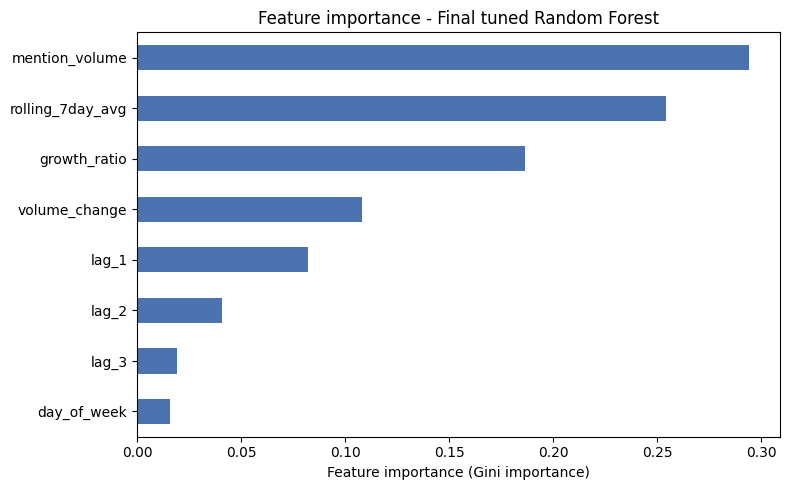

mention_volume      0.294314
rolling_7day_avg    0.254085
growth_ratio        0.186388
volume_change       0.107867
lag_1               0.081916
lag_2               0.040790
lag_3               0.018968
day_of_week         0.015672
dtype: float64

In [67]:
importances = pd.Series(
    final_rf_model.feature_importances_,
    index=enhanced_features
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="#4C72B0")
plt.gca().invert_yaxis()
plt.xlabel("Feature importance (Gini importance)")
plt.title("Feature importance - Final tuned Random Forest")
plt.tight_layout()
plt.show()

importances

The final Random Forest relies primarily on activity magnitude and recent baseline information. mention_volume is the most important feature with an importance of approximately 0.294, followed by rolling_7day_avg at 0.254 and growth_ratio at 0.186. volume_change also contributes meaningfully at approximately 0.108.

The lag features contribute smaller amounts, while day_of_week has the lowest importance at approximately 0.016. This pattern is consistent with the intended trend-emergence task: the model mainly uses current activity, recent historical baseline and relative acceleration rather than relying heavily on calendar effects.

Feature importance should be interpreted as an indication of how much each feature contributes to Random Forest splits rather than as proof of causal influence.

# 11. Final Moderator Dashboard

The dashboard is a lightweight presentation layer on top of the final model. A moderator selects a subreddit and observation date, the validated recent-activity filter is applied and the highest-ranked topics are shown using the selected community review budget. `Model score` is used rather than `probability` because the Random Forest scores have not been calibrated as literal real-world probabilities.

In [68]:
def create_moderator_dashboard(data, probabilities, selected_date, community, top_k=5, min_recent=3, show_actual=False):
    d = data.copy(); d["model_score"] = probabilities; d["date"] = pd.to_datetime(d["date"]); selected_date = pd.to_datetime(selected_date)
    d["recent_4day_activity"] = d["mention_volume"] + d["lag_1"] + d["lag_2"] + d["lag_3"]
    d = d[(d["date"] == selected_date) & (d["subreddit"] == community) & (d["recent_4day_activity"] >= min_recent)].nlargest(top_k, "model_score").reset_index(drop=True)
    if d.empty: print(f"No candidates found for r/{community} on {selected_date.date()}."); return pd.DataFrame()
    d["Rank"] = range(1, len(d) + 1); d["Model score"] = (d["model_score"] * 100).map(lambda x: f"{x:.1f}%")
    d["Today"] = d["mention_volume"].round().astype(int); d["Yesterday"] = d["lag_1"].round().astype(int); d["7-day avg"] = d["rolling_7day_avg"].map(lambda x: f"{x:.1f}"); d["Growth"] = d["growth_ratio"].map(lambda x: f"{x:.2f}×"); d["Change"] = d["volume_change"].round().astype(int).map(lambda x: f"{x:+d}")
    columns = ["Rank", "topic", "Model score", "Today", "Yesterday", "7-day avg", "Growth", "Change"]
    if show_actual: d["Actual next day"] = d["target_trend_next_day"].map({1: "Trend", 0: "No trend"}); columns.append("Actual next day")
    return d[columns].rename(columns={"topic": "Topic"})

def show_moderator_dashboard(data, probabilities, selected_date, community, top_k=5, min_recent=3, show_actual=False):
    selected_date = pd.to_datetime(selected_date); dashboard = create_moderator_dashboard(data, probabilities, selected_date, community, top_k, min_recent, show_actual)
    print("=" * 70); 
    print(f"REDDIT EMERGING TREND DASHBOARD - r/{community}"); 
    print("=" * 70); 
    print(f"Observation date:      {selected_date.date()}"); 
    print(f"Predicted trend date:  {(selected_date + pd.Timedelta(days=1)).date()}"); 
    print(f"Review budget:         Top {top_k} topics"); print(f"Candidate filter:      Recent 4-day activity >= {min_recent}")
    if not dashboard.empty: display(dashboard.style.hide(axis="index"))
    return dashboard

In [69]:
_ = show_moderator_dashboard(test_df, test_probs, "2021-10-31", "memes", top_k=chosen_k, min_recent=chosen_min_recent, show_actual=True)

REDDIT EMERGING TREND DASHBOARD - r/memes
Observation date:      2021-10-31
Predicted trend date:  2021-11-01
Review budget:         Top 5 topics
Candidate filter:      Recent 4-day activity >= 3


Rank,Topic,Model score,Today,Yesterday,7-day avg,Growth,Change,Actual next day
1,Halloween celebrations,61.5%,12,1,3.4,3.50×,+11,Trend
2,meme culture,19.3%,17,3,12.6,1.35×,+14,No trend
3,Music Streaming and Listening Experience,4.4%,3,2,2.3,1.31×,+1,No trend
4,The Office Characters and Relationships,1.8%,2,0,0.4,4.67×,+2,No trend
5,Social Media Humor,0.3%,2,0,1.3,1.56×,+2,No trend


The dashboard demonstrates how the predictive model can be translated into a practical moderator-facing decision-support tool. For the selected subreddit and observation date, candidate topics are filtered using recent activity, ranked by the Random Forest model score, and limited to the validated Top-5 review budget.

In the demonstration, Halloween celebrations receives the highest model score and is subsequently observed as a genuine next-day trend, while the remaining shortlisted topics do not become trends. This example illustrates how the system can prioritise topics for moderator attention without presenting model scores as guaranteed probabilities.

The Actual next day column is shown only for retrospective evaluation and demonstration. In a live deployment, this information would not yet be available and would therefore be hidden.

# 12. Final Evaluation Summary

In [70]:
summary_hyperparams = {
    "n_estimators": 100,
    **selected_params,
    "random_state": 42
}
test_pr_auc = average_precision_score(y_test, test_probs); community_test_row = community_test_results.iloc[0]
final_summary = pd.DataFrame([
    {"Item": "Model", "Value": "Random Forest (scikit-learn)"},
    {"Item": "Hyperparameters", "Value": str(summary_hyperparams)},
    {"Item": "Training data", "Value": "Train + Validation; chronological Test held out for final evaluation"},
    {"Item": "Candidate filter", "Value": f"Recent 4-day activity >= {chosen_min_recent}"},
    {"Item": "Deployment method", "Value": f"Top {chosen_k} topics within each subreddit per day"},
    {"Item": "PR-AUC (test)", "Value": round(test_pr_auc, 4)},
    {"Item": f"Precision@{chosen_k} (test, all community-days)", "Value": community_test_row["Precision@k all community-days"]},
    {"Item": f"Precision@{chosen_k} (test, trend community-days)", "Value": community_test_row["Precision@k trend community-days"]},
    {"Item": f"Recall@{chosen_k} (test, trend community-days)", "Value": community_test_row["Recall@k trend community-days"]},
    {"Item": "Average shortlist size", "Value": community_test_row["Avg shortlist size"]}
])
pd.set_option("display.max_colwidth", None); final_summary

,Item,Value
0,Model,Random Forest (scikit-learn)
1,Hyperparameters,"{'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 10, 'class_weight': 'balanced', 'random_state': 42}"
2,Training data,Train + Validation; chronological Test held out for final evaluation
3,Candidate filter,Recent 4-day activity >= 3
4,Deployment method,Top 5 topics within each subreddit per day
5,PR-AUC (test),0.0815
6,"Precision@5 (test, all community-days)",0.0026
7,"Precision@5 (test, trend community-days)",0.1949
8,"Recall@5 (test, trend community-days)",0.8173
9,Average shortlist size,4.6


The completed system is best used as a community-specific trend-prioritisation tool for Reddit moderators rather than a fully automatic trend classifier. The model analyses recent topic-level activity within an individual subreddit, removes largely inactive candidates, ranks the remaining topics according to their likelihood of emerging, and presents moderators with a fixed Top-5 shortlist.

The final Random Forest uses max_depth=10, min_samples_leaf=10, and balanced class weighting. On the held-out test period, it achieves a PR-AUC of 0.0815. On community-days containing genuine trends, the Top-5 shortlist achieves 19.49% precision and 81.73% recall, with an average of 4.6 topics presented for review.

The high trend-day recall indicates that the shortlist captures a large proportion of genuine emerging topics when trends occur. However, the very low precision across all community-days reflects the extreme rarity of trend events and means that many ordinary daily shortlists will not contain a future trend. The system should therefore support moderator awareness and prioritisation rather than automatically triggering moderation actions.

The results also show several limitations. The project relies on topic labels already provided by the dataset, has been evaluated on five selected communities, and performance varies somewhat across historical periods. A live system would require continuous Reddit data collection, automatic topic identification, broader cross-community validation, and evaluation with real moderators before practical deployment.